In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#导入依赖
from data.dataset import convert_to_k_space, k_space_to_img, normalize_npy
from data.mask import get_mask
from models.network import Network,data_consistency
from models.guided_diffusion_modules.unet import UNet

#将 Numpy 转化为模型所需张量
def to_tensor(x):
    return torch.from_numpy(x).unsqueeze(0).unsqueeze(0).to(device)

def to_numpy(x):
    return x.squeeze().detach().cpu().numpy()

Using device: cuda


Loaded GT shape: (256, 256)


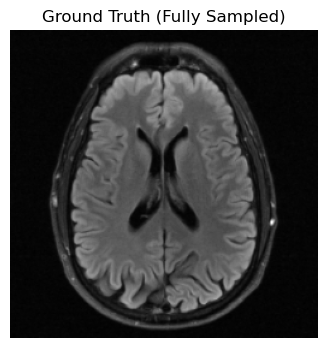

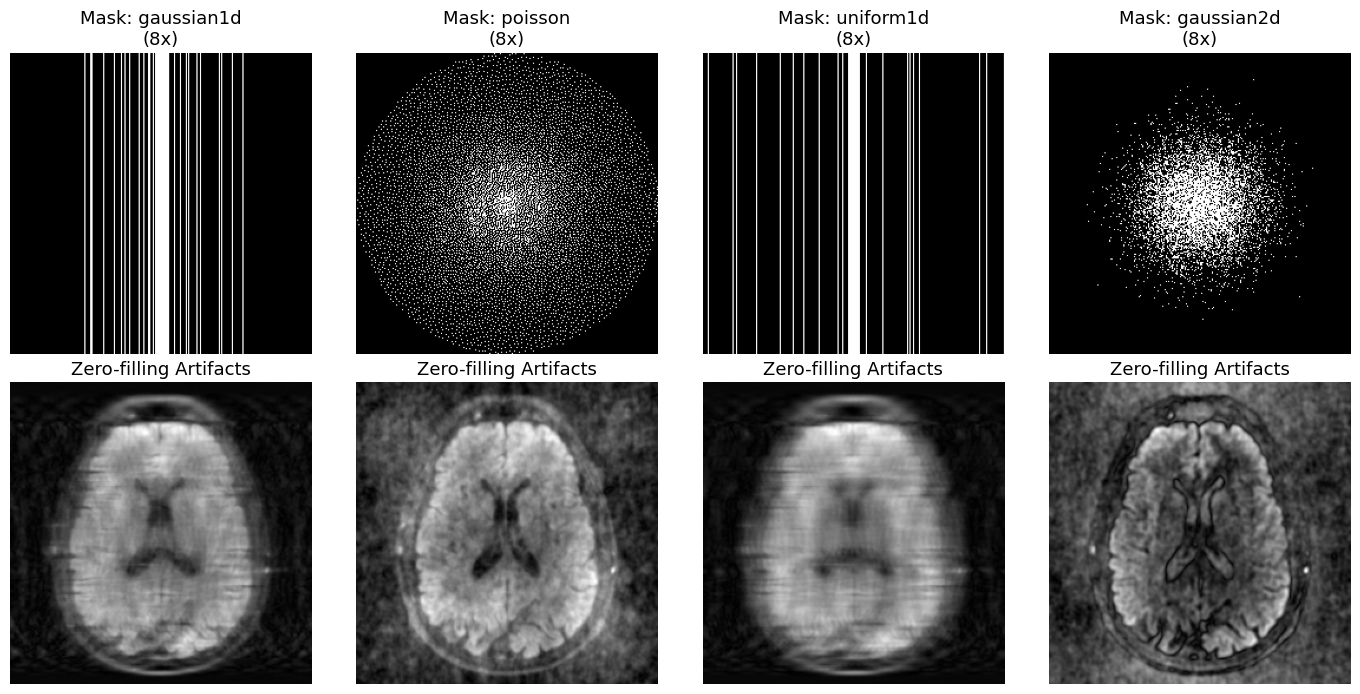

In [2]:
#1. Ground Truth
gt_img = np.load('GT.npy').astype(np.float32)
gt_img = normalize_npy(gt_img)
img_size = gt_img.shape
print(f"Loaded GT shape: {img_size}")

plt.figure(figsize=(4, 4))
plt.imshow(gt_img, cmap='gray')
plt.title("Ground Truth (Fully Sampled)")
plt.axis('off')
plt.show()

# 2. 生成不同的 Masks 及 Zero-filling 图像
mask_configs = [
    {'type': 'gaussian1d', 'acc': 8},
    {'type': 'poisson', 'acc': 8},
    {'type': 'uniform1d', 'acc': 8},
    {'type': 'gaussian2d', 'acc': 8}
]

mask_dict = {}
cond_img_dict = {}
sub_kspace_dict = {}

k_full = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(gt_img)))

for config in mask_configs:
    m_type, acc = config['type'], config['acc']
    name = f"{m_type}\n({acc}x)"
    
    # 生成 mask
    mask = get_mask(img_size=img_size, acc_factor=acc, type=m_type)
    
    # 欠采样与零填充
    k_sub = k_full * mask.astype(np.float32)
    cond_img = k_space_to_img(k_sub).astype(np.float32)
    cond_img = normalize_npy(cond_img)
    
    mask_dict[name] = mask
    cond_img_dict[name] = cond_img
    sub_kspace_dict[name] = k_sub

# 画图
N = len(mask_configs)
fig, axes = plt.subplots(2, N, figsize=(N * 3.5, 7))

for i, name in enumerate(mask_dict.keys()):
    # 第一行：Masks
    axes[0, i].imshow(mask_dict[name], cmap='gray')
    axes[0, i].set_title(f"Mask: {name}", fontsize=13)
    axes[0, i].axis('off')
    
    # 第二行：Zero-filling
    axes[1, i].imshow(cond_img_dict[name], cmap='gray')
    axes[1, i].set_title("Zero-filling Artifacts", fontsize=13)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# U-Net 网络参数 
unet_kwargs = {
    "in_channel": 2, 
    "out_channel": 1, 
    "inner_channel": 64, 
    "channel_mults": [1, 2, 4, 8], 
    "attn_res": [8], 
    "num_head_channels": 32, 
    "res_blocks": 2, 
    "dropout": 0.2, 
    "image_size": img_size[0] 
}

base_checkpoint = "checkpoints/ori.pth"
distilled_checkpoint = "checkpoints/ssdm.pth"

def load_model(ckpt_path, n_timestep):
    # 设定 schedule
    beta_schedule = {
        "train": {"schedule": "cosine", "n_timestep": n_timestep},
        "test": {"schedule": "cosine", "n_timestep": n_timestep}
    }
    
    # 网络初始化
    model = Network(unet=unet_kwargs, beta_schedule=beta_schedule).to(device)
    
    # 加载权重
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device), strict=False)
        print(f"Successfully loaded: {ckpt_path}")
    else:
        print(f"Warning: {ckpt_path} not found. Using randomly initialized weights for demo.")
        
    model.set_new_noise_schedule(device=device, phase='test')
    model.eval()
    return model


print("\nLoading Distilled SSDM Model (1-Step)...")
model_ssdm = load_model(distilled_checkpoint, n_timestep=1)


Loading Distilled SSDM Model (1-Step)...
Successfully loaded: checkpoints/ssdm.pth


In [ ]:
# 导入写好的评估函数
from eval_metrics import compute_metrics

data_files = [ 'ex1.npy', 'ex2.npy',  'ex4.npy', 'ex5.npy']
mask_configs = [
    {'type': 'gaussian1d', 'acc': 12},
    {'type': 'gaussian1d', 'acc': 8},
    {'type': 'gaussian1d', 'acc': 10},
    {'type': 'poisson', 'acc': 15}
]

ssdm_results = []
zf_results = []
gt_results = []

# 分别保存 Zero-filling 和 SSDM 的绘图标题（包含指标）
zf_titles = []
ssdm_titles = []

print("Running Distilled SSDM (1-Step) on  different examples and masks...")

with torch.no_grad():
    for img_file, config in zip(data_files, mask_configs):
        m_type, acc = config['type'], config['acc']
        
        # 1. 读取独立的图像数据并归一化
        try:
            img_np = np.load(img_file).astype(np.float32)
            img_np = normalize_npy(img_np)
        except FileNotFoundError:
            print(f"Warning: {img_file} not found! Using GT.npy as fallback.")
            img_np = np.load('GT.npy').astype(np.float32)
            img_np = normalize_npy(img_np)
            
        gt_results.append(img_np)
        
        # 2. 生成对应的 Mask
        mask = get_mask(img_size=img_np.shape, acc_factor=acc, type=m_type)
        
        # 3. 生成欠采样 k-space 和 Zero-filling 图像
        k_full = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(img_np)))
        k_sub = k_full * mask.astype(np.float32)
        
        cond_img = k_space_to_img(k_sub).astype(np.float32)
        cond_img = normalize_npy(cond_img)
        zf_results.append(cond_img)
        
        zf_titles.append(f"Zero-filling\n{m_type} ({acc}x)")
        
        # 4. 转换为 Tensor 并进行单步重建
        cond_t = to_tensor(cond_img)
        mask_t = to_tensor(mask)
        sub_k_t = torch.from_numpy(k_sub).unsqueeze(0).to(device)
        
        recon, _ = model_ssdm.restoration(
            y_cond=cond_t, 
            mask=mask_t, 
            sample_num=1, 
            sub_kspace=sub_k_t
        )
        
        # Data Consistency
        recon = data_consistency(recon, sub_k_t, mask_t, device=recon.device)
        recon_np = to_numpy(recon)
        ssdm_results.append(recon_np)
        
        # 计算 SSDM 1-Step 的指标
        ssdm_psnr, ssdm_ssim = compute_metrics(img_np, recon_np)
        ssdm_titles.append(f"Proposed (1-Step)\nPSNR: {ssdm_psnr:.2f} | SSIM: {ssdm_ssim:.2f}")

# --- 画 3xN 的终极对比图 ---
N = len(data_files)
fig, axes = plt.subplots(3, N, figsize=(N * 4.5, 12))

for i in range(N):
    # 第一行: Zero-filling
    axes[0, i].imshow(zf_results[i], cmap='gray')
    axes[0, i].set_title(zf_titles[i], fontsize=13)
    axes[0, i].axis('off')
    
    # 第二行: Proposed 1-Step SSDM
    axes[1, i].imshow(ssdm_results[i], cmap='gray')
    axes[1, i].set_title(ssdm_titles[i], fontsize=14, color='darkred', weight='bold')
    axes[1, i].axis('off')
    
    # 第三行: Ground Truth
    axes[2, i].imshow(gt_results[i], cmap='gray')
    axes[2, i].set_title(f"Ground Truth", fontsize=13)
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()